# 🚀 Bonus Coding Task (Important for Assessment)

## Task Description

Perform classification on the **Breast Cancer dataset** using multiple models and compare their performance.

---

## Objectives

1. Load dataset (sklearn - breast cancer)  
2. Train models:
   - Random Forest  
   - AdaBoost  
   - SVM (RBF Kernel)  
3. Compare:
   - Accuracy  
   - Precision  
   - Recall  
4. Print Feature Importance (Random Forest)  
5. Plot Confusion Matrix  

---


Random Forest Accuracy: 0.96
Random Forest Precision: 0.96
Random Forest Recall: 0.99
----------------------------------------
AdaBoost Accuracy: 0.96
AdaBoost Precision: 0.96
AdaBoost Recall: 0.99
----------------------------------------
SVM Accuracy: 0.95
SVM Precision: 0.92
SVM Recall: 1.00
----------------------------------------


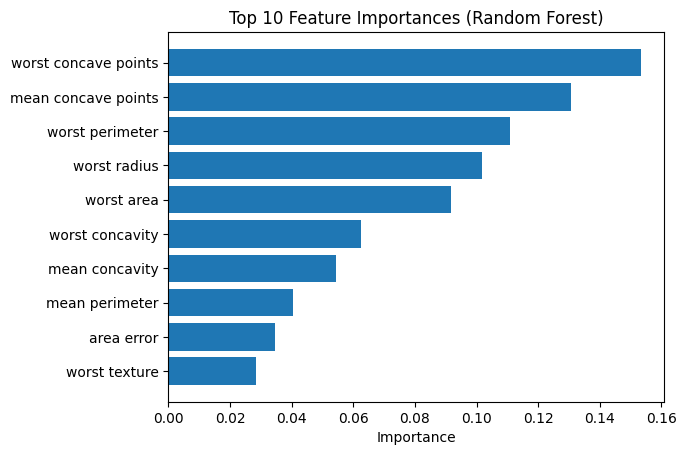

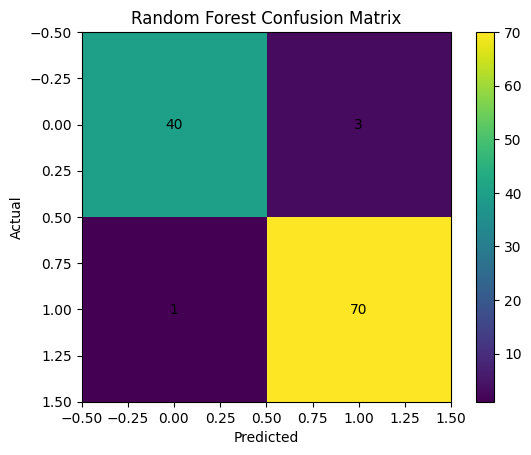

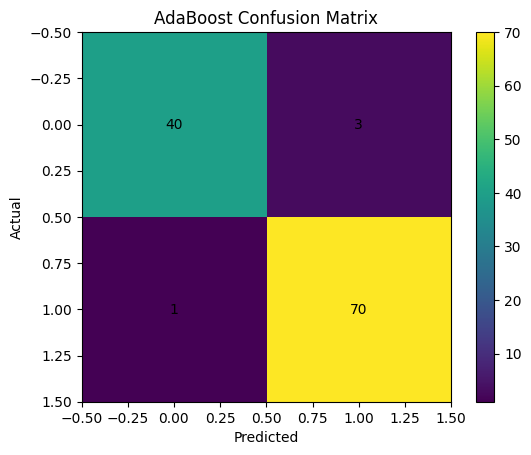

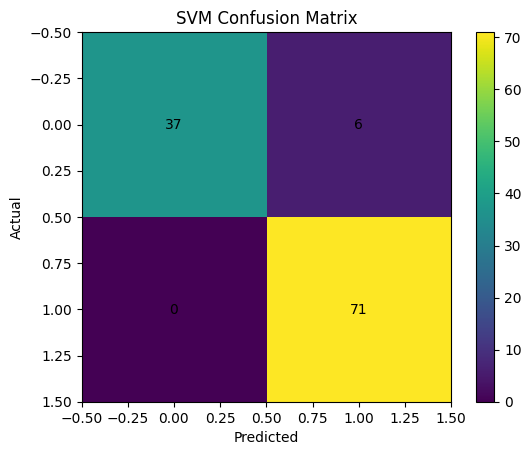

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
rf = RandomForestClassifier()
ada = AdaBoostClassifier()
svm = SVC(kernel='rbf')

# Train
rf.fit(X_train, y_train)
ada.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)
ada_pred = ada.predict(X_test)
svm_pred = svm.predict(X_test)

# Evaluation Function
def evaluate(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    print(f"{model_name} Accuracy: {acc:.2f}")
    print(f"{model_name} Precision: {prec:.2f}")
    print(f"{model_name} Recall: {rec:.2f}")
    print("-"*40)

# Evaluate Models
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, ada_pred, "AdaBoost")
evaluate(y_test, svm_pred, "SVM")

# Feature Importance (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance")
plt.show()

# Confusion Matrix Plot
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.show()


plot_cm(y_test, rf_pred, "Random Forest Confusion Matrix")
plot_cm(y_test, ada_pred, "AdaBoost Confusion Matrix")
plot_cm(y_test, svm_pred, "SVM Confusion Matrix")